# Export Anndata for Seurat Interoperability

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [29]:
import os
import sys
from pathlib import Path
import pandas as pd
import scanpy as sc
import scipy.sparse
from scipy.io import mmwrite
import zipfile, gzip, tempfile

In [30]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR
base_dir = BASE_DIR

adata_dir = base_dir / "data/h5ad/export_02/02a_scvi"
ref_data_dir = "/home/workspace/DRG/MC_private_folder/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/05_reference" # Reference dataset; configure in paths.py before removing hardcoded path

# New unified export root
export_root = base_dir / "data/rds"

# Two separate dataset-specific directories
adata_outdir = export_root / "xenium"
refdata_outdir = export_root / "refdata"

output_dirs = [adata_outdir, refdata_outdir]
print(output_dirs)

[PosixPath('/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/xenium'), PosixPath('/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/refdata')]


In [31]:
adata_outdir

PosixPath('/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/xenium')

In [32]:
adata = sc.read_h5ad(os.path.join(adata_dir, "ModelA_475_adata-scvi.h5ad"))
refdata = sc.read_h5ad(os.path.join(ref_data_dir, "adata-reference.h5ad"))

adata_list = [adata, refdata]
dataset_names = ["adata", "refdata"]

In [33]:
# adata = sc.read_h5ad(os.path.join(adata_dir, "ModelA_475_adata-scvi.h5ad"))
# refdata = sc.read_h5ad(ref_data_dir)

# adata_list = [adata, refdata]
# dataset_names = ["adata", "refdata"]

In [34]:
adata.obsm['X_scVI_ModelA_475'].shape

(72778, 10)

## Prepare data

In [35]:
genes_only_in_adata = set(adata.var_names) - set(refdata.var_names)
print(len(genes_only_in_adata))
genes_only_in_adata = sorted(list(genes_only_in_adata))
genes_only_in_adata[:20]  # preview first 20

4


['Ccn1', 'Pclaf', 'Tafa1', 'Tafa5']

In [36]:
# Standardize gene names from reference processed data

aliases = {"Ccn1": "Cyr61", "Pclaf": "Kiaa0101", "Tafa1": "Fam19a1", "Tafa5": "Fam19a5"}

for gene, alias in aliases.items():
    print(f"\nChecking {gene} and alias {alias}:")

    print("  adata:")
    print(f"    {gene}  > {gene in adata.var_names}")
    print(f"    {alias} > {alias in adata.var_names}")

    print("  refdata:")
    print(f"    {gene}  > {gene in refdata.var_names}")
    print(f"    {alias} > {alias in refdata.var_names}")


Checking Ccn1 and alias Cyr61:
  adata:
    Ccn1  > True
    Cyr61 > False
  refdata:
    Ccn1  > False
    Cyr61 > True

Checking Pclaf and alias Kiaa0101:
  adata:
    Pclaf  > True
    Kiaa0101 > False
  refdata:
    Pclaf  > False
    Kiaa0101 > False

Checking Tafa1 and alias Fam19a1:
  adata:
    Tafa1  > True
    Fam19a1 > False
  refdata:
    Tafa1  > False
    Fam19a1 > True

Checking Tafa5 and alias Fam19a5:
  adata:
    Tafa5  > True
    Fam19a5 > False
  refdata:
    Tafa5  > False
    Fam19a5 > True


In [37]:
old_names = ["Cyr61", "Fam19a1", "Fam19a5"]

for name in old_names:
    print("In refdata", name, ":", name in refdata.var_names)

In refdata Cyr61 : True
In refdata Fam19a1 : True
In refdata Fam19a5 : True


In [38]:
# mapping: what refdata HAS > what we WANT it to be
rename_map = {"Cyr61": "Ccn1", "Fam19a1": "Tafa1", "Fam19a5": "Tafa5"}

# apply renaming safely
refdata.var.index = refdata.var.index.to_series().replace(rename_map)

# ensure AnnData internal references are updated
refdata.var_names_make_unique()

In [39]:
genes_only_in_adata = set(adata.var_names) - set(refdata.var_names)
print(len(genes_only_in_adata))
genes_only_in_adata = sorted(list(genes_only_in_adata))
genes_only_in_adata[:20]  # preview first 20

1


['Pclaf']

In [40]:
for ad in adata_list:
    if "counts" in ad.layers:
        ad.X = ad.layers["counts"].copy()
    else:
        raise ValueError(f"'counts' layer missing in object with shape {ad.shape}")

## Export components

In [41]:
layer_name = "counts"

for ad, outdir in zip(adata_list, output_dirs):

    output_zip = outdir / f"{layer_name}_matrix.zip"
    outdir.mkdir(parents=True, exist_ok=True)

    # Ensure var index has a name
    gene_id_key = ad.var.index.name or "gene_name"
    ad.var.index.name = gene_id_key

    # Features table (ensembl_id, gene_name, feature_type)
    gene_df = ad.var.reset_index()
    genes = gene_df[[gene_id_key]].copy()
    genes["gene_name"] = gene_df[gene_id_key].values
    genes["feature_type"] = "Gene Expression"

    # Barcodes
    barcodes = pd.DataFrame(ad.obs.index)

    # Cell metadata
    cell_metadata = ad.obs.reset_index()
    cell_metadata.rename(columns={"index": "barcode"}, inplace=True)

    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_path = Path(tmp_dir)

        # Matrix
        if layer_name in ad.layers:
            X = ad.layers[layer_name].T
        else:
            X = ad.X.T

        with gzip.open(tmp_path / "matrix.mtx.gz", "wb") as f:
            mmwrite(f, scipy.sparse.csc_matrix(X))

        # Features
        genes.to_csv(
            tmp_path / "features.tsv.gz",
            sep="\t",
            index=False,
            header=False,
            compression="gzip",
        )

        # Barcodes
        barcodes.to_csv(
            tmp_path / "barcodes.tsv.gz",
            sep="\t",
            index=False,
            header=False,
            compression="gzip",
        )

        # Cell metadata
        cell_metadata.to_csv(tmp_path / "cell_metadata.csv", index=False)

        # Zip output
        with zipfile.ZipFile(output_zip, "w") as zipf:
            for fname in [
                "matrix.mtx.gz",
                "features.tsv.gz",
                "barcodes.tsv.gz",
                "cell_metadata.csv",
            ]:
                zipf.write(tmp_path / fname, arcname=fname)

    print(output_zip)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/xenium/counts_matrix.zip
/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/refdata/counts_matrix.zip


In [42]:
# Metadata export

for ad, outdir in zip(adata_list, output_dirs):

    save_dir = outdir / "metadata"
    save_dir.mkdir(parents=True, exist_ok=True)

    ad.obs.to_csv(save_dir / "cell-metadata.csv")
    ad.var.to_csv(save_dir / "feature-metadata.csv")

    print(f"Exported metadata to: {save_dir}")

Exported metadata to: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/xenium/metadata
Exported metadata to: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/refdata/metadata


In [43]:
# Dimensional Reductions export

latent_key_map = {"xenium": "X_scVI_ModelA_475", "refdata": "X_scVI"}

for ad, outdir in zip(adata_list, output_dirs):

    dataset_name = outdir.name
    save_dir = outdir / "reductions"
    save_dir.mkdir(parents=True, exist_ok=True)

    # PCA
    if "X_pca" in ad.obsm:
        pca = pd.DataFrame(ad.obsm["X_pca"], index=ad.obs_names)
        pca.columns = ["PC_" + str(i + 1) for i in range(pca.shape[1])]
        pca.to_csv(save_dir / "pca.csv")
        print("Exported PCA:", save_dir / "pca.csv")

    # LATENT
    if dataset_name in latent_key_map:
        latent_key = latent_key_map[dataset_name]

        if latent_key in ad.obsm:
            latent = pd.DataFrame(ad.obsm[latent_key], index=ad.obs_names)
            latent.columns = ["latent_" + str(i + 1) for i in range(latent.shape[1])]
            latent.to_csv(save_dir / "latent_representation.csv")
            print(
                "Exported latent (" + latent_key + "):",
                save_dir / "latent_representation.csv",
            )
        else:
            print("Latent key", latent_key, "not found for", dataset_name)
    else:
        print("No latent key mapping for dataset:", dataset_name)

    # UMAP
    if "X_umap" in ad.obsm:
        umap = pd.DataFrame(ad.obsm["X_umap"], index=ad.obs_names)
        umap.columns = ["umap_" + str(i + 1) for i in range(umap.shape[1])]
        umap.to_csv(save_dir / "umap.csv")
        print("Exported UMAP:", save_dir / "umap.csv")

Exported latent (X_scVI_ModelA_475): /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/xenium/reductions/latent_representation.csv
Exported latent (X_scVI): /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/refdata/reductions/latent_representation.csv
Exported UMAP: /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/refdata/reductions/umap.csv


In [51]:
adata

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'log1p'
    obsm: 'X_scVI_ModelA_475', 'spatial'
    layers: 'counts', 'log1p', 'normalized'

In [50]:
refdata

AnnData object with n_obs × n_vars = 36241 × 28737
    obs: 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden', 'artifact', 'class', 'cell_type', 'batch', 'cell_label'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_label_colors', 'neighbors', 'umap', 'batch_colors'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

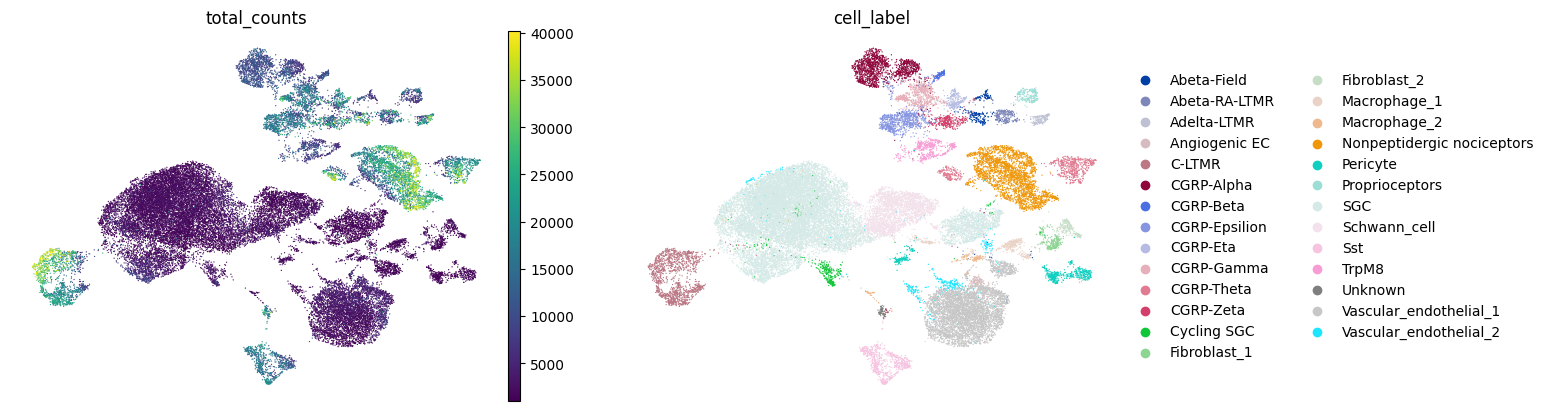

In [48]:
sc.pl.umap(refdata, color=['total_counts', 'cell_label'], legend_fontsize=10, frameon=False)

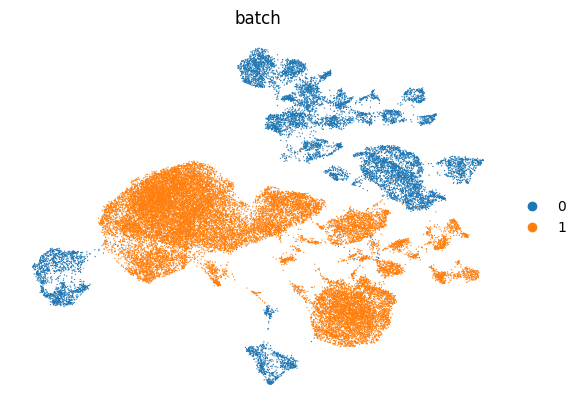

In [49]:
sc.pl.umap(refdata, color=['batch'], legend_fontsize=10, frameon=False)